# Options Pricing & Implied Volatility — SPY

A from-scratch Black-Scholes implementation, a Newton-Raphson/Brent implied-vol
solver, and real option-chain data. Each section runs a stage of the pipeline
and comments on what the output means. See `README.md` for the full write-up.

**Run order matters** — later cells reuse earlier results. Run from the repo
root so `src` imports resolve (the first cell handles the path).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root, when run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.black_scholes import bs_price, delta, gamma, vega, theta
from src.implied_vol import implied_vol, solve_chain
from src.data_fetch import (fetch_option_chain, filter_liquid,
                            get_risk_free_rate, get_dividend_yield)
from src.plotting import plot_smile, plot_term_structure, atm_iv_by_expiry

## 1. Black-Scholes from scratch

The price of a European call is `S·e^{-qT}·N(d1) − K·e^{-rT}·N(d2)`: the
expected present value of receiving the stock conditional on exercise, minus
the PV of paying the strike times the risk-neutral probability of exercise.
Sanity-check against the standard textbook case (full test suite:
`python -m src.test_black_scholes`).

In [2]:
S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20   # ATM, 1y, 20% vol

print(f"call  = {bs_price(S, K, T, r, sigma, option_type='call'):.4f}   (textbook: 10.4506)")
print(f"put   = {bs_price(S, K, T, r, sigma, option_type='put'):.4f}    (textbook:  5.5735)")
print(f"delta = {delta(S, K, T, r, sigma):.4f}, gamma = {gamma(S, K, T, r, sigma):.4f}, "
      f"vega = {vega(S, K, T, r, sigma):.2f}, theta = {theta(S, K, T, r, sigma):.2f}/yr")

# put-call parity: C - P = S - K·e^{-rT}, holds to machine precision
c = bs_price(S, K, T, r, sigma, option_type='call')
p = bs_price(S, K, T, r, sigma, option_type='put')
print(f"parity residual = {c - p - (S - K*np.exp(-r*T)):.2e}")

call  = 10.4506   (textbook: 10.4506)
put   = 5.5735    (textbook:  5.5735)
delta = 0.6368, gamma = 0.0188, vega = 37.52, theta = -6.41/yr
parity residual = 0.00e+00


## 2. Real option chain data

Pull SPY's chain (12 expiries) via yfinance, cached to `data/` one CSV per day.
The market price is the bid/ask midpoint during market hours; on an overnight
pull Yahoo has cleared its quotes (zero bids everywhere), which the loader
detects — it falls back to the prior session's `lastPrice` and anchors
time-to-expiry to that session's 4pm ET close. The liquidity filter then
reports exactly what it dropped and why.

In [3]:
df, spot, stale = fetch_option_chain("SPY")
r = get_risk_free_rate()      # 13-week T-bill (^IRX), continuous compounding
q = get_dividend_yield("SPY", spot)   # trailing-12m dividends / spot
print(f"r = {r:.4%}, q = {q:.4%}")
liquid, filter_diag = filter_liquid(df, stale)

  loaded cached chain from SPY_chain_2026-07-09.csv (2920 contracts, spot=745.29 @ 2026-07-08 15:59 EDT)
  [data quality] 99% of contracts have zero bid -> market is closed / quotes cleared. Using lastPrice from the session ending 2026-07-08 16:00 EDT as the market price.


r = 3.6554%, q = 1.2460%
  liquidity filter [stale/lastPrice]: 2920 -> kept 1788 (61%); dropped: 1132 volume<10, 0 no_last_price


## 3. Implied vol: Newton-Raphson with a Brent fallback

Vega > 0 makes price monotone in vol, so a unique implied vol exists whenever
the price is inside the no-arbitrage bounds. Newton (using our analytic vega)
converges quadratically where vega is healthy; where it's tiny — deep ITM/OTM
or near expiry — the Newton step explodes and we fall back to Brent, which
only needs a sign change. Prices outside the arbitrage bounds get `None`, and
the failure count is reported: it's a data-quality diagnostic, not a bug.

In [4]:
# round-trip check first: price at a known vol, invert, recover it
p_known = bs_price(100, 100, 1.0, 0.05, 0.20)
iv, method = implied_vol(p_known, 100, 100, 1.0, 0.05)
print(f"round trip: true 0.20 -> recovered {iv:.10f} via {method}")

p_otm = bs_price(100, 150, 0.5, 0.05, 0.35)          # deep OTM: Newton fails
iv2, method2 = implied_vol(p_otm, 100, 150, 0.5, 0.05)
print(f"deep OTM:   true 0.35 -> recovered {iv2:.10f} via {method2}")

# now the whole chain
solved, solve_diag = solve_chain(liquid, spot, r, q)

round trip: true 0.20 -> recovered 0.2000000000 via newton
deep OTM:   true 0.35 -> recovered 0.3500000000 via brent
  IV solver: 1788 contracts -> 774 Newton (43.3%), 947 Brent fallback (53.0%), 67 failed (3.7%)


Failures should cluster in the shortest expiries and deep-ITM strikes, where a
stale last price can sit below intrinsic value — a price that admits **no**
implied vol at all:

In [5]:
failed = solved[solved["iv_method"] == "failed"].copy()
failed["moneyness"] = failed["strike"] / spot
print("failed solves by expiry:")
print(failed.groupby(failed["expiry"].dt.date).size().to_string())
print("\nmoneyness of failures:",
      failed["moneyness"].describe()[["min", "50%", "max"]].round(3).to_dict())

failed solves by expiry:
expiry
2026-07-09    13
2026-07-10    14
2026-07-13     3
2026-07-14     3
2026-07-15     3
2026-07-17    13
2026-07-24     7
2026-07-31    11

moneyness of failures: {'min': 0.496, '50%': 0.966, 'max': 1.06}


## 4. The volatility smile

Under Black-Scholes assumptions this line would be flat. Instead: the classic
equity skew — OTM puts price far richer than ATM (crash risk + leverage effect
+ insurance demand). Calls and puts are plotted separately; they agree where
OTM and diverge where ITM (intrinsic-heavy prices make IV hypersensitive to
staleness, plus a small American-exercise premium). Desk convention is to keep
the OTM side of each wing — the second chart.

smile expiry: 2026-08-07


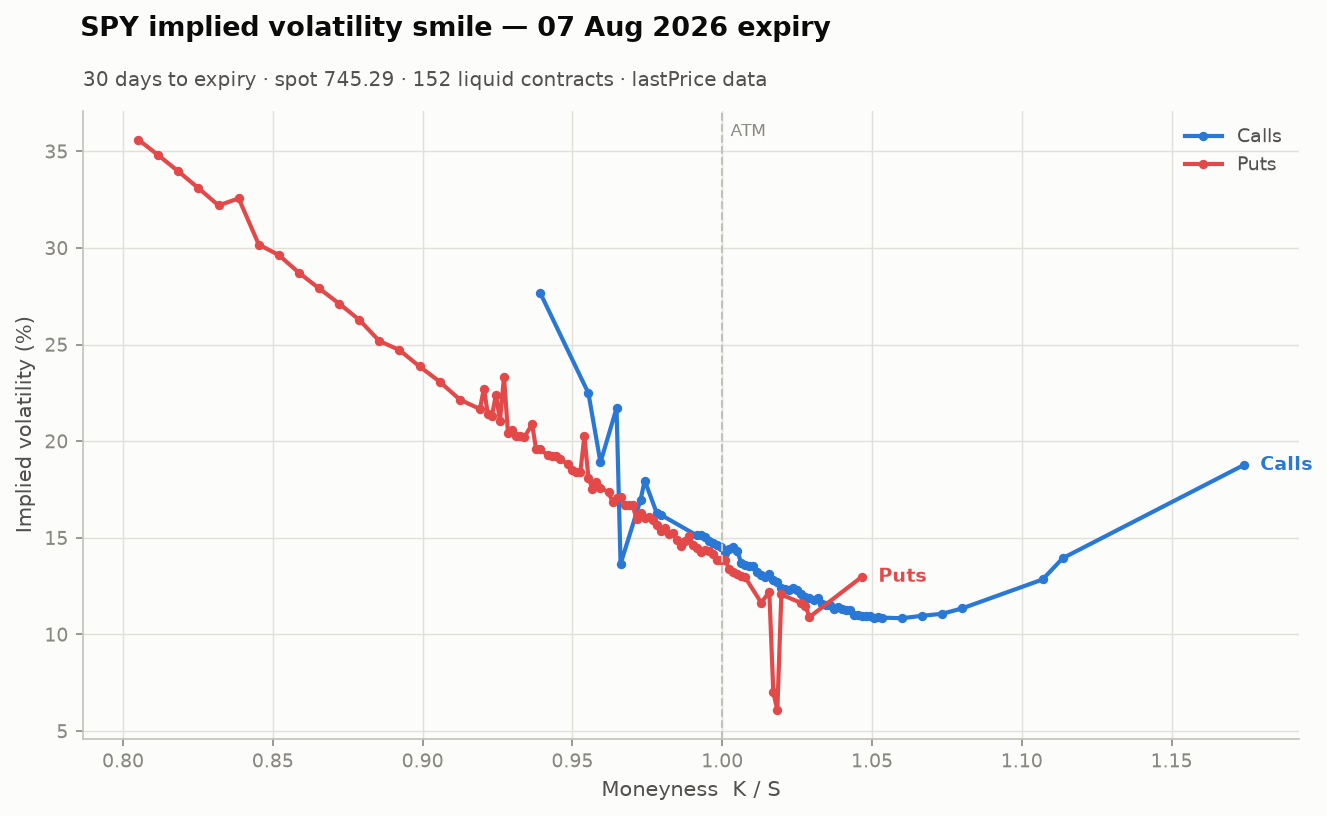

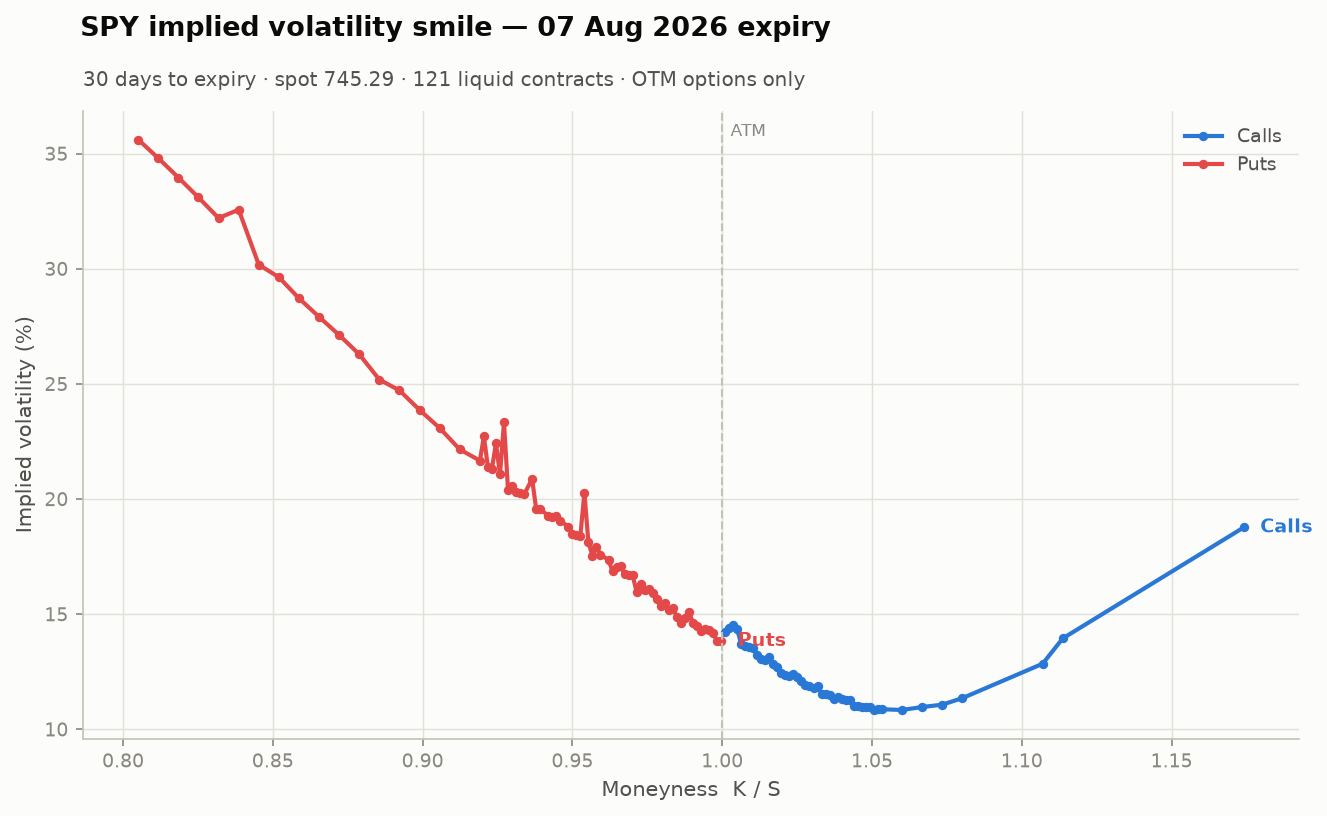

In [6]:
from src.main import pick_smile_expiry
exp = pick_smile_expiry(solved)                       # expiry nearest ~30d out
print(f"smile expiry: {exp:%Y-%m-%d}")
p1 = plot_smile(solved, spot, exp, f"smile_{exp:%Y-%m-%d}.png",
                note="lastPrice data" if stale else "bid/ask midpoints")
p2 = plot_smile(solved, spot, exp, f"smile_otm_{exp:%Y-%m-%d}.png",
                note="OTM options only", otm_only=True)
from IPython.display import Image, display
display(Image(str(p1)), Image(str(p2)))

## 5. ATM term structure

Implied vol interpolated at K = spot for every expiry. An upward slope
(contango) is the normal calm-market shape: near-term realized vol is expected
to stay low, longer horizons carry a vol risk premium. Watch for two artifacts:
1–2 day IVs are the noisiest points on the chart, and expiries spanning a
weekend dip because T is measured in calendar days.

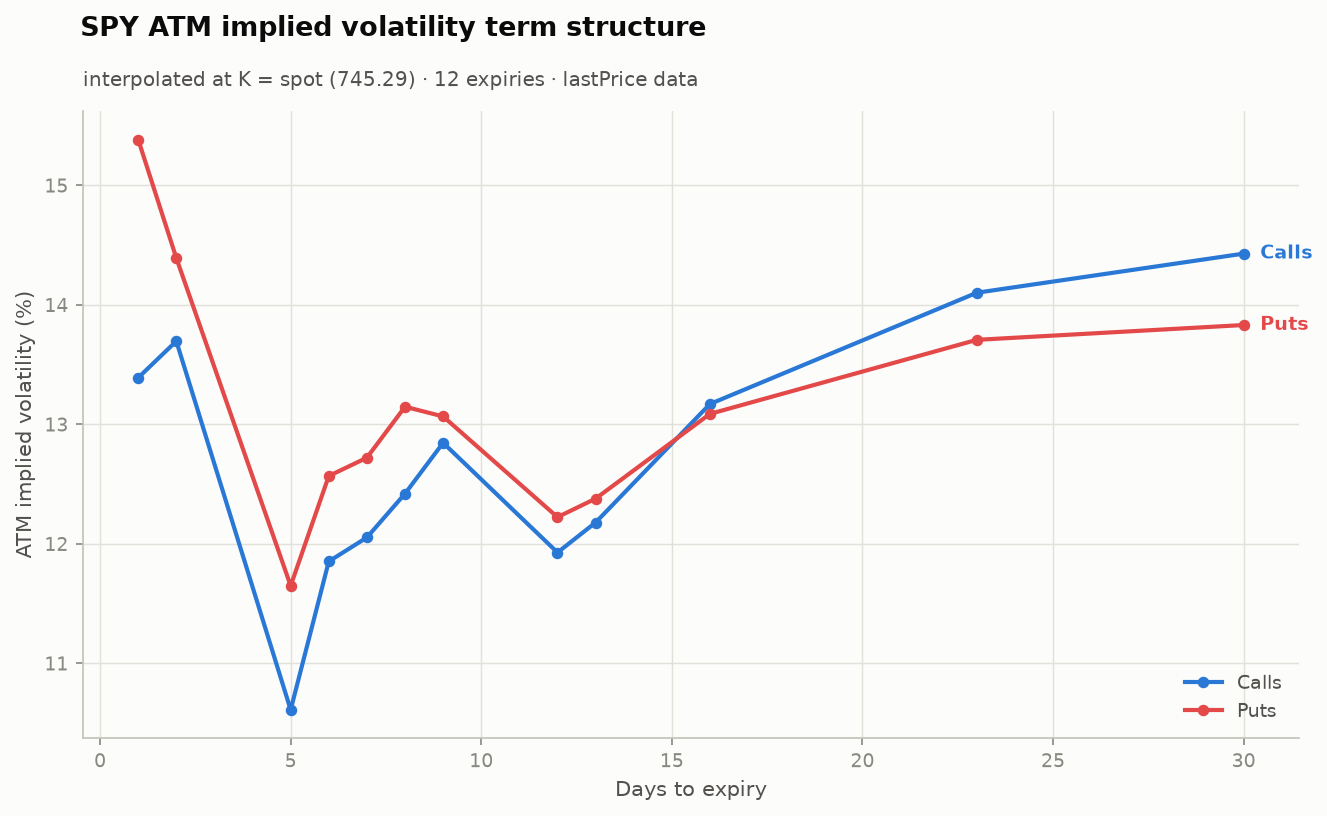

ATM vol <=1wk: 12.8%   ~1mo: 14.0%   -> upward-sloping


In [7]:
p3, atm = plot_term_structure(solved, spot,
                              note="lastPrice data" if stale else "bid/ask midpoints")
display(Image(str(p3)))
atm_short = atm[atm["T_days"] <= 7]["atm_iv"].mean()
atm_1m = atm[atm["T_days"] > 20]["atm_iv"].mean()
print(f"ATM vol <=1wk: {atm_short:.1%}   ~1mo: {atm_1m:.1%}   -> "
      f"{'upward' if atm_1m > atm_short else 'downward'}-sloping")

## 6. Stretch: earnings vol premium (NFLX)

One snapshot can't show the vol *crush* in time series, but it shows the same
economics cross-sectionally: the first expiry after the earnings date carries
the announcement jump, so its ATM IV spikes above both the pre-earnings expiry
and the longer-dated baseline. Differencing total implied variance across the
event (`σ₂²T₂ − σ₁²T₁`) backs out the market-implied earnings-day move.
`python -m src.earnings_vol` runs this end-to-end; re-run it the morning after
the print for the realized before/after crush.

  loaded cached chain from NFLX_chain_2026-07-09.csv (1479 contracts, spot=75.59 @ 2026-07-08 15:59 EDT)
  [data quality] 73% of contracts have zero bid -> market is closed / quotes cleared. Using lastPrice from the session ending 2026-07-08 16:00 EDT as the market price.
  liquidity filter [stale/lastPrice]: 1479 -> kept 588 (40%); dropped: 891 volume<10, 0 no_last_price


  IV solver: 588 contracts -> 293 Newton (49.8%), 238 Brent fallback (40.5%), 57 failed (9.7%)
NFLX earnings 2026-07-16: pre-expiry IV 39.1%, post-expiry IV 66.6%
market-implied earnings-day move ~ 10.0% of spot


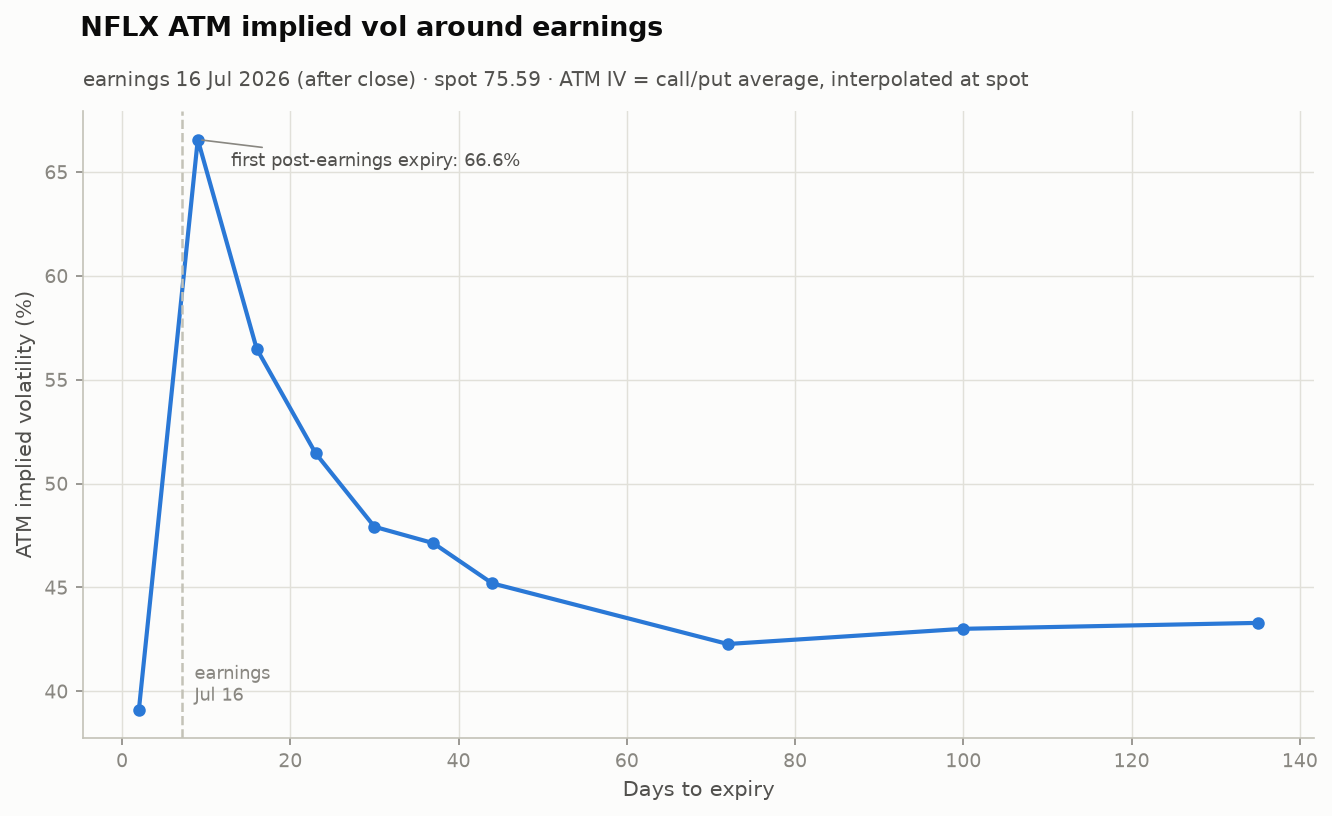

In [8]:
from src.earnings_vol import next_earnings_date

t = "NFLX"
earnings = next_earnings_date(t)
ndf, nspot, nstale = fetch_option_chain(t, max_expiries=10)
nliquid, _ = filter_liquid(ndf, nstale)
nsolved, _ = solve_chain(nliquid, nspot, r, get_dividend_yield(t, nspot))

natm = atm_iv_by_expiry(nsolved, nspot)
natm_avg = (natm.groupby("expiry")
                .agg(T_days=("T_days", "first"), atm_iv=("atm_iv", "mean"))
                .reset_index().sort_values("T_days"))
earnings_naive = earnings.tz_localize(None)
pre = natm_avg[natm_avg["expiry"] < earnings_naive].tail(1)
post = natm_avg[natm_avg["expiry"] >= earnings_naive].head(1)
s1, T1 = pre["atm_iv"].iloc[0], pre["T_days"].iloc[0] / 365
s2, T2 = post["atm_iv"].iloc[0], post["T_days"].iloc[0] / 365
move = np.sqrt(max(s2**2 * T2 - s1**2 * T1, 0))
print(f"{t} earnings {earnings:%Y-%m-%d}: pre-expiry IV {s1:.1%}, "
      f"post-expiry IV {s2:.1%}")
print(f"market-implied earnings-day move ~ {move:.1%} of spot")
display(Image(str(pathlib.Path.cwd().parent / "outputs" / f"earnings_{t}.png")))